# 2D Design Template

# Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating machine learning model, as well as using metrics to measure the accuracy of your model.


## Deliverables

You need to submit this notebook along with the raw dataset.

## Students Submission

Student's Name:
- Name 1
- Name 2
- ...

### Context and Problem Statement

Describe your background, user persona, and problem statement here

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put Python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (excel, python, etc) yet. Include this dataset in your submission.
- Explain each column of your dataset (can use comment or markdown).
- State which column is the dependent variable (target) and explain how it is related to your problem statement.
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable.

In [427]:
FILENAME: str = "Food_Security_data_E_All_Data_(Normalized).csv"
FEATURES: list[str] = [
    "Area Code",
    "Year",
    "Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)",
    "Gross domestic product per capita, PPP, (constant 2021 international $)",
    "Per capita food supply variability (kcal/cap/day)",
    "Percentage of population using at least basic drinking water services (percent)",
    "Percentage of population using at least basic sanitation services (percent)",  #
    # "Percentage of children under 5 years of age who are stunted (modelled estimates) (percent)",
    "Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)",
    "Prevalence of obesity in the adult population (18 years and older) (percent)",
    "Prevalence of anemia among women of reproductive age (15-49 years) (percent)",
    "Minimum dietary energy requirement (kcal/cap/day)",
    # "Prevalence of low birthweight (percent)",
]
TARGET: str = "Prevalence of undernourishment (percent) (annual value)"

In [428]:
df = pd.read_csv(FILENAME)[["Area Code", "Item", "Year", "Value"]].replace("nan", np.nan)
df = df[(df["Item"].isin([*FEATURES, TARGET])) & (df["Area Code"] >= 1000)]
df.head()

,Area Code,Item,Year,Value
212240,5000,Dietary energy supply used in the estimation o...,2000,2709
212241,5000,Dietary energy supply used in the estimation o...,2001,2705
212242,5000,Dietary energy supply used in the estimation o...,2002,2707
212243,5000,Dietary energy supply used in the estimation o...,2003,2713
212244,5000,Dietary energy supply used in the estimation o...,2004,2723


### Clean & Analyze your data

Use Python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent).\
    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values).*
- Calculate Descriptive Statistics and other statistical analysis.
- Visualization with meaningful analysis description.

In [429]:
df_pivoted = df.pivot_table(
    index=["Area Code", "Year"],
    columns="Item",
    values="Value",
    aggfunc="first",
).reset_index()
df_pivoted

Item,Area Code,Year,Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day),"Gross domestic product per capita, PPP, (constant 2021 international $)",Minimum dietary energy requirement (kcal/cap/day),Per capita food supply variability (kcal/cap/day),Percentage of children under 5 years of age who are overweight (modelled estimates) (percent),Percentage of population using at least basic drinking water services (percent),Percentage of population using at least basic sanitation services (percent),Prevalence of anemia among women of reproductive age (15-49 years) (percent),Prevalence of obesity in the adult population (18 years and older) (percent),Prevalence of undernourishment (percent) (annual value)
0,5000,2000,2709,12770,1801,10,5.3,82,56,29.3,8.7,12.8
1,5000,2001,2705,12905,1804,7,5.3,82,56,29,9,13
2,5000,2002,2707,13093,1807,8,5.4,82,57,28.8,9.3,13.2
3,5000,2003,2713,13403,1810,11,5.4,83,58,28.7,9.5,12.9
4,5000,2004,2723,13915,1813,13,5.4,83,60,28.5,9.8,12.7
...,...,...,...,...,...,...,...,...,...,...,...,...
1061,9011,2021,3243,19507,1867,10,8.3,NaN,NaN,19.3,15,2.8
1062,9011,2022,3278,20095,1871,11,8.4,NaN,NaN,19.6,15.5,2.7
1063,9011,2023,3300,20950,1873,18,8.5,NaN,NaN,20.1,16.1,2.7
1064,9011,2024,3287,21738,1876,22,8.6,NaN,NaN,NaN,16.7,2.6


In [430]:
df_pivoted.columns[df_pivoted.isna().any()]

Index(['Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)',
       'Gross domestic product per capita, PPP, (constant 2021 international $)',
       'Per capita food supply variability (kcal/cap/day)',
       'Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)',
       'Percentage of population using at least basic drinking water services (percent)',
       'Percentage of population using at least basic sanitation services (percent)',
       'Prevalence of anemia among women of reproductive age (15-49 years) (percent)',
       'Prevalence of obesity in the adult population (18 years and older) (percent)',
       'Prevalence of undernourishment (percent) (annual value)'],
      dtype='str', name='Item')

In [431]:
df_cleaned = df_pivoted.dropna().replace("<0.1", "0").replace("<2.5", "0").astype(np.float64)
df_cleaned.describe()

Item,Area Code,Year,Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day),"Gross domestic product per capita, PPP, (constant 2021 international $)",Minimum dietary energy requirement (kcal/cap/day),Per capita food supply variability (kcal/cap/day),Percentage of children under 5 years of age who are overweight (modelled estimates) (percent),Percentage of population using at least basic drinking water services (percent),Percentage of population using at least basic sanitation services (percent),Prevalence of anemia among women of reproductive age (15-49 years) (percent),Prevalence of obesity in the adult population (18 years and older) (percent),Prevalence of undernourishment (percent) (annual value)
count,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,5300.424023,2011.568741,2883.036179,19778.681621,1818.509407,21.360347,6.828075,84.929088,71.296671,26.613893,17.550651,9.558321
std,186.917942,6.903631,409.576827,17273.306084,83.375027,21.275804,3.041490,16.298107,25.993594,11.304878,11.204716,8.370099
min,5000.000000,2000.000000,1977.000000,1813.000000,1655.000000,3.000000,1.600000,34.000000,14.000000,7.300000,2.500000,0.000000
25%,5203.000000,2006.000000,2565.000000,6135.000000,1763.000000,11.000000,4.800000,83.000000,51.500000,18.250000,7.850000,3.200000
50%,5303.000000,2012.000000,2891.000000,14331.000000,1819.000000,16.000000,6.600000,90.000000,80.000000,27.800000,17.000000,7.600000
75%,5401.000000,2018.000000,3144.000000,24283.000000,1863.500000,25.500000,8.500000,97.000000,93.500000,32.450000,24.050000,14.750000
max,5802.000000,2023.000000,3910.000000,72455.000000,1967.000000,228.000000,22.400000,100.000000,100.000000,52.900000,58.600000,38.000000


In [432]:
df_cleaned

Item,Area Code,Year,Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day),"Gross domestic product per capita, PPP, (constant 2021 international $)",Minimum dietary energy requirement (kcal/cap/day),Per capita food supply variability (kcal/cap/day),Percentage of children under 5 years of age who are overweight (modelled estimates) (percent),Percentage of population using at least basic drinking water services (percent),Percentage of population using at least basic sanitation services (percent),Prevalence of anemia among women of reproductive age (15-49 years) (percent),Prevalence of obesity in the adult population (18 years and older) (percent),Prevalence of undernourishment (percent) (annual value)
0,5000.0,2000.0,2709.0,12770.0,1801.0,10.0,5.3,82.0,56.0,29.3,8.7,12.8
1,5000.0,2001.0,2705.0,12905.0,1804.0,7.0,5.3,82.0,56.0,29.0,9.0,13.0
2,5000.0,2002.0,2707.0,13093.0,1807.0,8.0,5.4,82.0,57.0,28.8,9.3,13.2
3,5000.0,2003.0,2713.0,13403.0,1810.0,11.0,5.4,83.0,58.0,28.7,9.5,12.9
4,5000.0,2004.0,2723.0,13915.0,1813.0,13.0,5.4,83.0,60.0,28.5,9.8,12.7
...,...,...,...,...,...,...,...,...,...,...,...,...
877,5802.0,2019.0,2558.0,5646.0,1735.0,12.0,3.4,67.0,43.0,30.2,12.1,17.9
878,5802.0,2020.0,2617.0,5428.0,1738.0,19.0,3.4,68.0,44.0,30.5,12.5,17.3
879,5802.0,2021.0,2602.0,5549.0,1740.0,19.0,3.5,69.0,44.0,30.9,12.8,18.2
880,5802.0,2022.0,2629.0,5662.0,1742.0,18.0,3.6,70.0,45.0,31.5,13.3,17.4


In [433]:
df_cleaned.dtypes

Item
Area Code                                                                                            float64
Year                                                                                                 float64
Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)    float64
Gross domestic product per capita, PPP, (constant 2021 international $)                              float64
Minimum dietary energy requirement (kcal/cap/day)                                                    float64
Per capita food supply variability (kcal/cap/day)                                                    float64
Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)        float64
Percentage of population using at least basic drinking water services (percent)                      float64
Percentage of population using at least basic sanitation services (percent)                          float64
Prevalence of 

<Axes: xlabel='Item', ylabel='Item'>

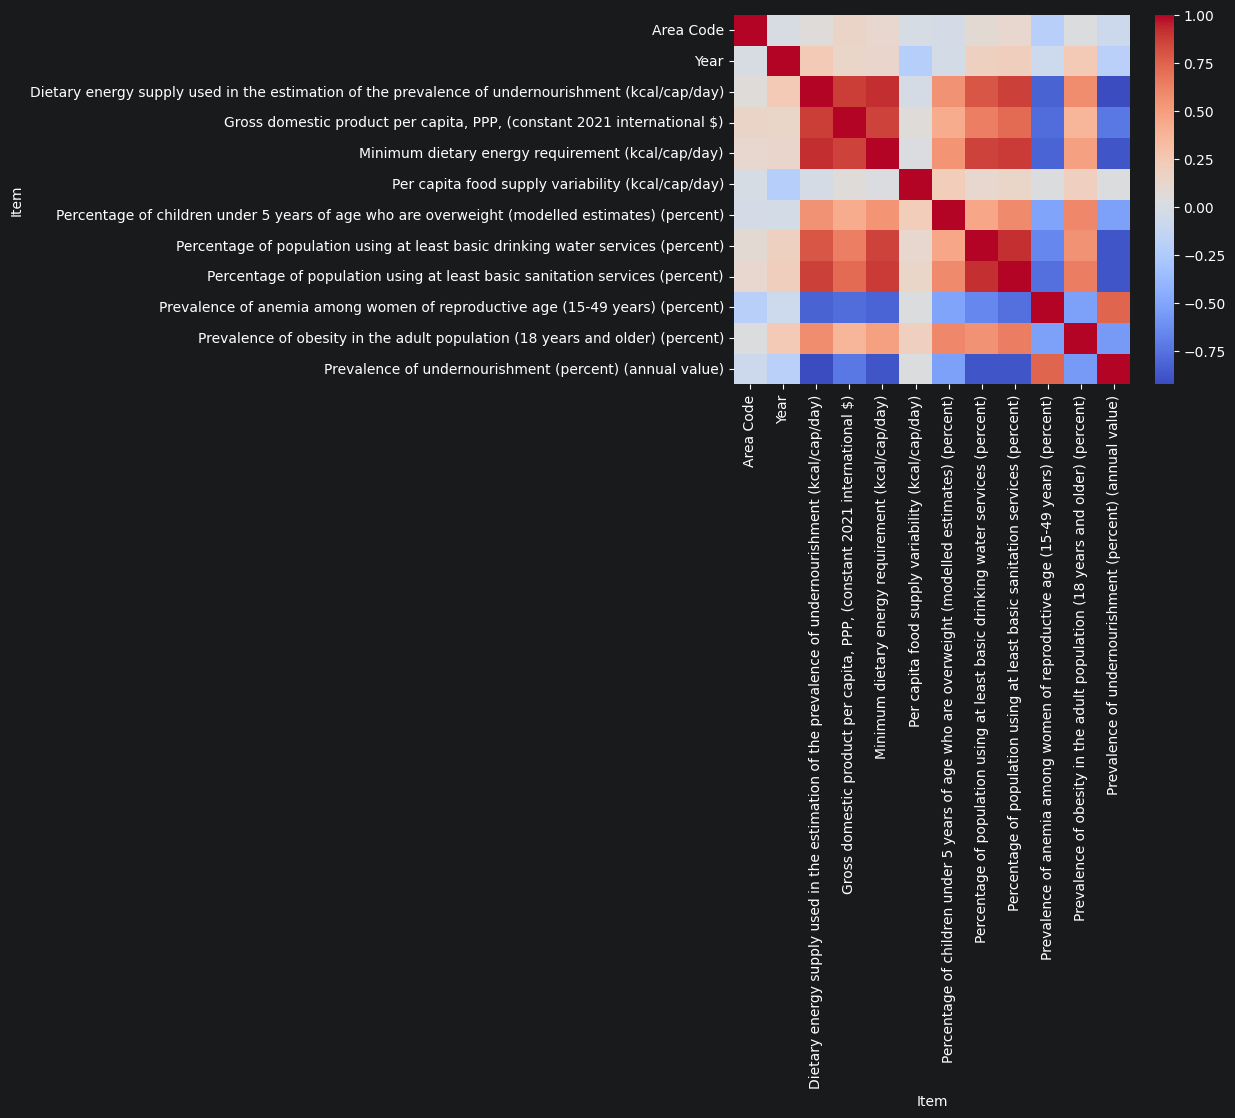

In [434]:
corr_matrix = df_cleaned.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm")

In [435]:
sorted_corr_target = corr_matrix[TARGET].sort_values(ascending=False, key=abs)
sorted_corr_target

Item
Prevalence of undernourishment (percent) (annual value)                                              1.000000
Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)   -0.922289
Percentage of population using at least basic drinking water services (percent)                     -0.882045
Minimum dietary energy requirement (kcal/cap/day)                                                   -0.880808
Percentage of population using at least basic sanitation services (percent)                         -0.878867
Prevalence of anemia among women of reproductive age (15-49 years) (percent)                         0.737258
Gross domestic product per capita, PPP, (constant 2021 international $)                             -0.726615
Prevalence of obesity in the adult population (18 years and older) (percent)                        -0.556262
Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)       -0.531461
Year 

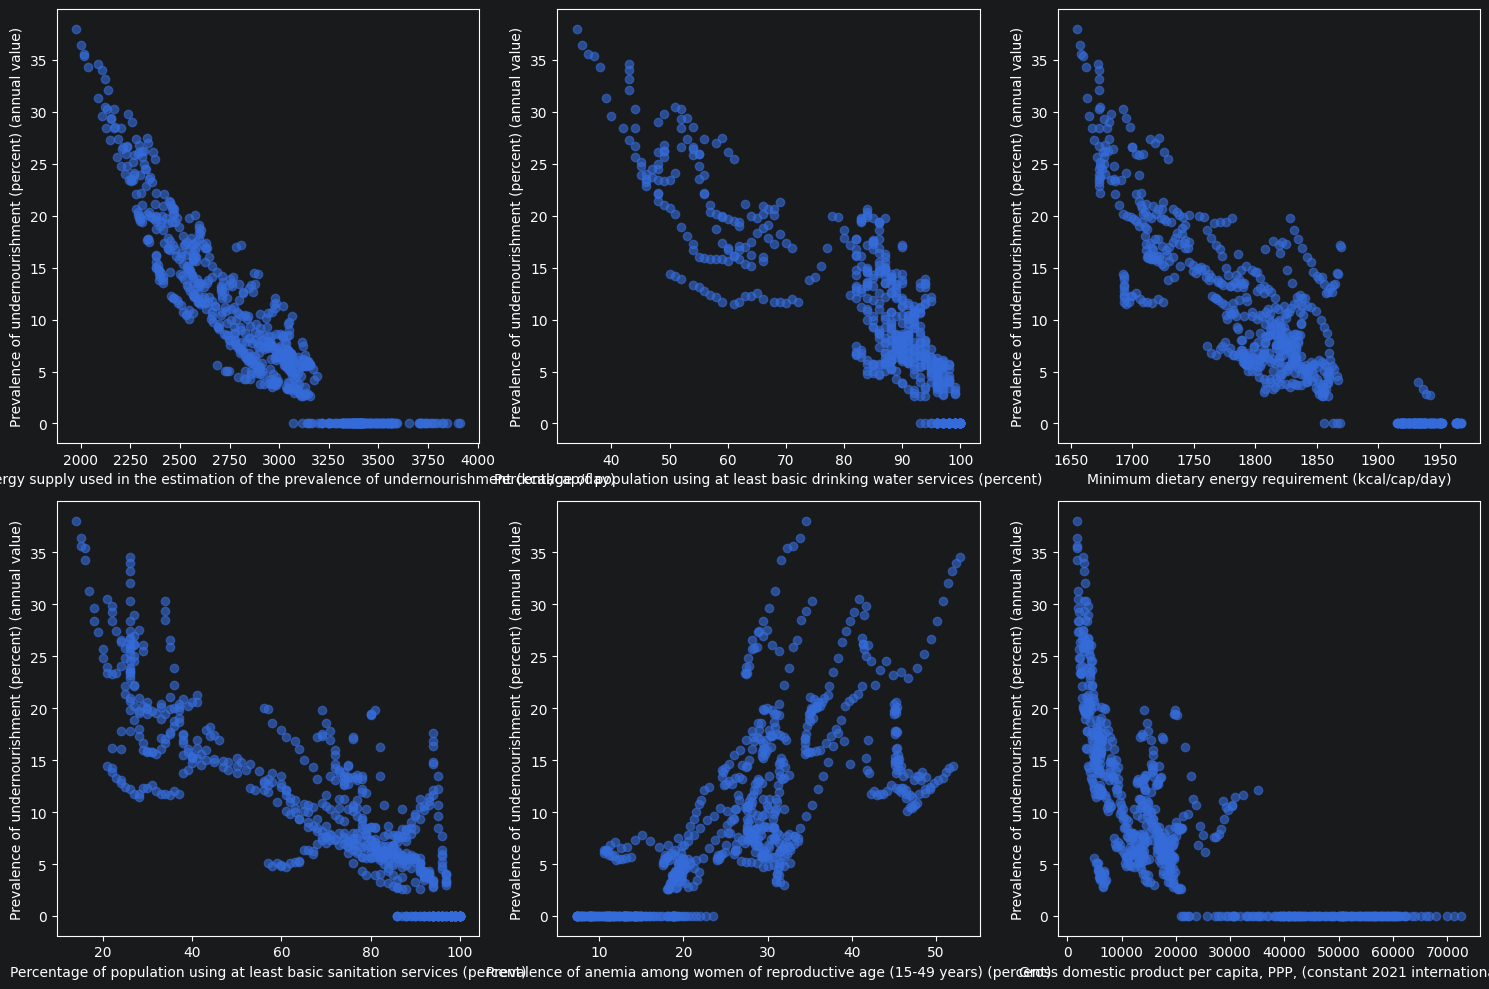

In [459]:
top6_cols = sorted_corr_target[1:7].index

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top6_cols):
    axes[i].scatter(df_cleaned[col], df_cleaned[TARGET], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

plt.tight_layout()
plt.show()

### Features and Target Preparation

Prepare features and target for model training.

In [437]:
class OrdinalEncoder:
    def __init__(self, *, unknown_value=-1, unknown_key="<unk>"):
        self.categories_ = []
        self.features_ = None
        self._mappings = []
        self._inv_mappings = []
        if unknown_value >= 0:
            raise ValueError("unknown_value must be negative to avoid valid-code collisions.")
        self.unknown_value_ = unknown_value
        self.unknown_key_ = unknown_key

    def fit(self, X):
        self.categories_ = []
        self.features_ = X.columns
        self._mappings = []
        self._inv_mappings = []

        for col in range(len(X.columns)):
            col_categories = pd.unique(X.iloc[:, col])

            self.categories_.append(col_categories)

            mapping, inv_mapping = {}, {}
            for idx, category in enumerate(col_categories):
                mapping[category] = idx
                inv_mapping[idx] = category
            inv_mapping[-1] = self.unknown_key_

            self._mappings.append(mapping)
            self._inv_mappings.append(inv_mapping)
        return self

    def _t(self, X, mappings, na_fill_value):
        if not self.categories_:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

        X = X.copy()
        for i, col in enumerate(X.columns):
            X[col] = X[col].map(mappings[i]).fillna(na_fill_value)
        return X

    def transform(self, X):
        return self._t(X, self._mappings, self.unknown_value_).astype(int)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return self._t(X, self._inv_mappings, self.unknown_key_)

In [438]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.features_ = None

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        self.features_ = X.columns
        return self

    def _check(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

    def transform(self, X):
        self._check(X)
        X = X.copy()
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        self._check(X)
        X = X.copy()
        return X * self.std_ + self.mean_

In [439]:
numerical_features = df_cleaned.select_dtypes(include="number").columns
categorical_features = df_cleaned.select_dtypes(exclude="number").columns

numerical_features, categorical_features

(Index(['Area Code', 'Year',
        'Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)',
        'Gross domestic product per capita, PPP, (constant 2021 international $)',
        'Minimum dietary energy requirement (kcal/cap/day)',
        'Per capita food supply variability (kcal/cap/day)',
        'Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)',
        'Percentage of population using at least basic drinking water services (percent)',
        'Percentage of population using at least basic sanitation services (percent)',
        'Prevalence of anemia among women of reproductive age (15-49 years) (percent)',
        'Prevalence of obesity in the adult population (18 years and older) (percent)',
        'Prevalence of undernourishment (percent) (annual value)'],
       dtype='str', name='Item'),
 Index([], dtype='str', name='Item'))

In [440]:
df_train, df_test = df_cleaned[df_cleaned["Year"] < 2020], df_cleaned[df_cleaned["Year"] >= 2020]

df_train.shape, df_test.shape

((575, 12), (116, 12))

In [441]:
# oe = OrdinalEncoder()
# df_train[categorical_features] = oe.fit_transform(df_train[categorical_features])
# df_test[categorical_features] = oe.transform(df_test[categorical_features])

ss = StandardScaler()
df_train[numerical_features] = ss.fit_transform(df_train[numerical_features])
df_test[numerical_features] = ss.transform(df_test[numerical_features])

### Building Model

Use python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

In [442]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.weights_ = None
        self.history_ = []

    def _predict(self, X):
        return (X @ self.weights_).squeeze()

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        return self._predict(X)

    def _cost(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / n_samples) * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))

        n_samples, n_features = X.shape
        self.weights_ = np.zeros((n_features,))
        self.history_ = []

        for _ in range(self.n_iters_):
            self.weights_ -= self.lr_ * self._cost_grad(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

        return self

In [443]:
X_train, y_train = df_train[FEATURES].to_numpy(), df_train[TARGET].to_numpy()
X_test, y_test = df_test[FEATURES].to_numpy(), df_test[TARGET].to_numpy()

len(X_train), len(X_test)

(575, 116)

In [444]:
lr = LinearRegression(n_iters=10000)
lr.fit(X_train, y_train)

Text(0, 0.5, 'Loss')

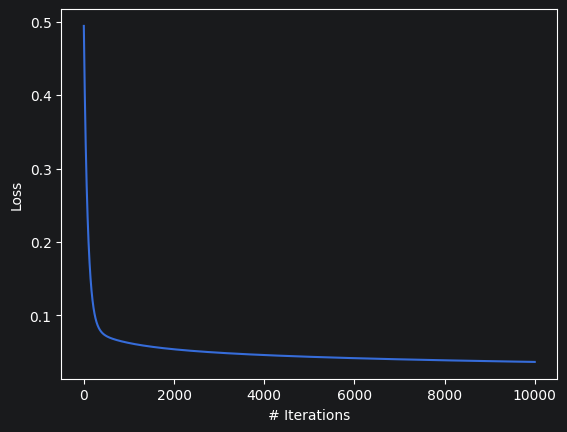

In [445]:
sns.lineplot(lr.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss")

In [446]:
feature_weight_pairs = list(zip(["<bias>", *FEATURES], lr.weights_.tolist()))
feature_weight_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

feature_weight_pairs

[('Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)',
  -0.5040678699123589),
 ('Percentage of population using at least basic drinking water services (percent)',
  -0.37407079363222323),
 ('Minimum dietary energy requirement (kcal/cap/day)', -0.11763817146844982),
 ('Per capita food supply variability (kcal/cap/day)', 0.10438010273939471),
 ('Percentage of population using at least basic sanitation services (percent)',
  -0.08289090042863945),
 ('Prevalence of anemia among women of reproductive age (15-49 years) (percent)',
  -0.07575877925019749),
 ('Gross domestic product per capita, PPP, (constant 2021 international $)',
  0.06630013997744125),
 ('Percentage of children under 5 years of age who are overweight (modelled estimates) (percent)',
  -0.03421059528498515),
 ('Year', -0.029750792940395152),
 ('Prevalence of obesity in the adult population (18 years and older) (percent)',
  -0.027072917996802486),
 ('Area Code', -0.0029373509

### Evaluating the Model

- Describe the metrics of your choice.
- Evaluate your model performance.

In [447]:
y_pred = lr.predict(X_test)

In [448]:
def r2_score(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true, axis=0)) ** 2))

In [449]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2).tolist())

In [450]:
r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(0.801134002490915, 0.18015246282248404)

### Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning.
- You can repeat the steps above to show the improvement as compared to the previous performance.

*Note: changing or adding more dataset is not allowed.*

In [451]:
class LinearRegressionLayer:
    def __init__(self, n_in, n_out):
        self.learnable_ = True
        # He initialization: unscaled N(0, 1) weights blow up through 3 ReLU
        # layers (pre-activations grow ~sqrt(n_in) per layer), which explodes
        # the loss in the first few iterations and permanently kills most
        # ReLU units, collapsing the model to a near-constant prediction.
        self.weights_ = np.random.randn(n_out, n_in + 1) * np.sqrt(2 / n_in)
        self.input_ = None
        self.weights_gradient_ = None

    def forward(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        self.input_ = X  # (n_samples, n_in + 1)
        return X @ self.weights_.T  # (n_samples, n_out)

    def backward(self, delta):  # (n_samples, n_out)
        self.weights_gradient_ = delta.T @ self.input_  # (n_out, n_in + 1)
        # Differentiate bias terms get 0
        return delta @ self.weights_[:, 1:]  # (n_samples, n_in)

In [452]:
class Relu:
    def __init__(self):
        self.learnable_ = False
        self.input_ = None

    def forward(self, X):  # (n_samples, n_in)
        self.input_ = X
        return np.maximum(0, X)

    def backward(self, delta):  # (n_samples, n_out)
        delta_relu = self.input_ > 0  # (n_samples, n_in)
        return delta * delta_relu  # Element-wise, n_in == n_out

In [453]:
class RegressiveMultilayerPerceptron:
    def __init__(self, layers, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.layers_ = layers
        self.history_ = []

    def predict(self, X):
        cur = X
        for layer in self.layers_:
            cur = layer.forward(cur)
        return cur.squeeze(-1)  # (n_samples,)

    def _cost(self, X, y):  # Same as single layer
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad_wrt_pred(self, X, y):
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return np.expand_dims((y_hat - y) / n_samples, axis=-1)  # (n_samples, 1)

    def _backpropagate(self, X, y):
        delta = self._cost_grad_wrt_pred(X, y)

        for layer in self.layers_[::-1]:
            delta = layer.backward(delta)
            if layer.learnable_:
                layer.weights_ -= self.lr_ * layer.weights_gradient_

    def fit(self, X, y):
        self.history_ = []

        for _ in range(self.n_iters_):
            self._backpropagate(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

In [454]:
mlp = RegressiveMultilayerPerceptron([
    LinearRegressionLayer(X_train.shape[1], 32),
    Relu(),
    LinearRegressionLayer(32, 16),
    Relu(),
    LinearRegressionLayer(16, 1),
], lr=0.001, n_iters=50000)
mlp.fit(X_train, y_train)

In [455]:
y_pred_mlp = mlp.predict(X_test)

r2_score(y_test, y_pred_mlp), root_mean_squared_error(y_test, y_pred_mlp)

(0.8521594314197147, 0.1339285894442463)

Text(0, 0.5, 'Loss')

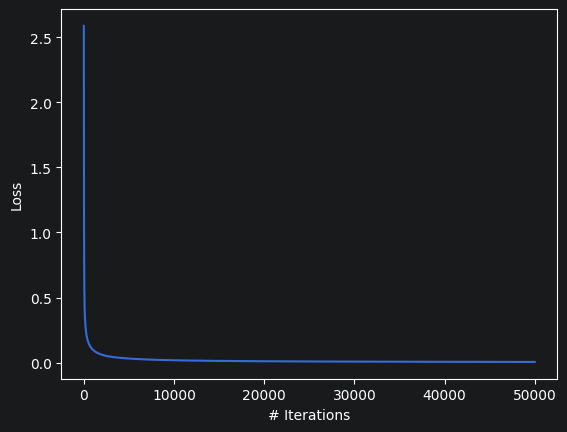

In [456]:
sns.lineplot(mlp.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss")

### Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion.